# Cross-Dataset Polyp Segmentation — Results Report

**Question:** can LoRA-adapted SAM match a specialist U-Net on the PraNet benchmark, and
generalize better to datasets neither model was trained on?

**Answer:** SAM-ViT-H with LoRA generalizes better. On the three unseen test splits it holds
mean Dice around 0.81, roughly 5 points above U-Net's 0.76, and its seen-to-unseen drop is
about half of U-Net's. U-Net still edges out SAM on the two splits both models were trained
on. MedSAM with LoRA trails both models on every split.

This notebook is a static report. Every table and chart below is computed at run time from
committed `results/*/seed*/metrics.json` files and the overlay PNGs saved during evaluation —
nothing here is retrained, re-evaluated, or hand-typed. `results/` is listed in `.gitignore`
(commit `a0b7e1e`, "derived data, mirrored to Drive") and is not part of a fresh clone. If
`results/` is missing, run `python aggregate_results.py` after pulling the Drive mirror
(`msu2026_checkpoints/results/`) into the repo root — see the README run-order step 4 — then
re-run this notebook with **Restart & Run All**.

**Two tiers, kept separate throughout.** The tables and charts through the qualitative gallery
below cover the trained prompt-free models only (U-Net, SAM+LoRA, MedSAM+LoRA) — no GPU, no
torch, no model weights, and no prompt hint at eval time. A separate section further down,
"Without fine-tuning — oracle-box baselines," renders the untrained vanilla SAM/MedSAM
baselines from `results/vanilla_sam` and `results/vanilla_medsam` when those files exist. They
are never merged into the trained-model tables or charts: a GT-derived box prompt makes them an
upper bound, not a fair peer. `05_benchmark.ipynb`'s zero-shot cell writes those two
`metrics.json` files (GPU, rebuilds the vanilla models live); this notebook only reads what it
already wrote.


In [1]:
# Dependencies: stdlib + pandas + matplotlib + Pillow. No torch, no GPU, no model code.
import sys
import csv
import statistics
from pathlib import Path

missing = []
for _mod in ("pandas", "matplotlib", "PIL"):
    try:
        __import__(_mod)
    except ImportError:
        missing.append(_mod)
if missing:
    raise ImportError(
        f"Missing dependencies: {missing}. This notebook needs only pandas, matplotlib, "
        f"and Pillow (PIL) — no torch. Install with: pip install pandas matplotlib Pillow"
    )
assert "torch" not in sys.modules, "torch should never be imported by this notebook"

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


def find_repo_root(start=None) -> Path:
    """Walk upward from `start` (default: this notebook's cwd) until a `.git` dir or
    `CLAUDE.md` file is found. Anchoring on `.git`/`CLAUDE.md` rather than `results/` matters:
    `results/` is gitignored and may not exist yet on a fresh clone, which is exactly the
    case this notebook needs to detect and report clearly, not silently fail on."""
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / ".git").exists() or (candidate / "CLAUDE.md").exists():
            return candidate
    raise RuntimeError(
        f"Could not find repo root (looked for .git or CLAUDE.md) walking up from {here}. "
        f"Run this notebook from inside the repo, or from its notebooks/ subfolder."
    )


REPO_ROOT = find_repo_root()
RESULTS_DIR = REPO_ROOT / "results"
if not RESULTS_DIR.is_dir():
    raise RuntimeError(
        f"'{RESULTS_DIR}' not found — results/ is gitignored and not part of a fresh clone. "
        f"Run `python aggregate_results.py` after pulling the Drive mirror "
        f"(msu2026_checkpoints/results/) into the repo root, or see README run-order step 4. "
        f"Then re-run this notebook with Restart & Run All."
    )

sys.path.insert(0, str(REPO_ROOT))
from src.results_summary import (  # noqa: E402  (path must be set first)
    discover_metrics, flatten, aggregate_by_model, MODEL_DISPLAY,
    SEEN_SPLITS, UNSEEN_SPLITS, ALL_SPLITS, tier_of,
)

# All data loading goes through src/results_summary.py — the same pure module
# aggregate_results.py uses to write results/summary/. No hand-parsing of metrics.json here,
# and model identity always comes from the folder name (`model_dir`), never the JSON "model"
# field — sam_vit_h/*/metrics.json literally says `"model": "sam_lora"`.
#
# Kept UNFILTERED here on purpose (both the "prompt-free" trained tier and the "oracle"
# vanilla-baseline tier land in rows/agg/agg_by_dir/trained_model_dirs) so the cell-3 std
# cross-check and the not_yet_run_dirs bookkeeping below still cover every model directory,
# oracle included. Each consuming cell below filters to one tier at the point of iteration —
# never here — via `tier_of(model_dir) == "prompt-free"` or `== "oracle"`.
discovered = discover_metrics([RESULTS_DIR])
rows = [flatten(model_dir, payload) for (model_dir, _seed), (payload, _src) in sorted(discovered.items())]
agg = aggregate_by_model(rows)

run_df = pd.DataFrame(rows)
agg_by_dir = {e["model_dir"]: e for e in agg}

trained_model_dirs = sorted({r["model_dir"] for r in rows})
not_yet_run_dirs = [d for d in MODEL_DISPLAY if d not in trained_model_dirs]

print(f"Repo root:   {REPO_ROOT}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Runs found:  {len(rows)} ({', '.join(sorted(f'{m}/seed{s}' for m, s in discovered))})")
print(f"Trained model dirs:   {trained_model_dirs}")
print(f"Designed, not yet run: {not_yet_run_dirs or '(none)'}")


Repo root:   /Users/mikkopalis/Desktop/msu2026summer_final_project
Results dir: /Users/mikkopalis/Desktop/msu2026summer_final_project/results
Runs found:  9 (medsam/seed42, medsam/seed43, medsam/seed44, sam_vit_h/seed42, sam_vit_h/seed43, sam_vit_h/seed44, unet/seed42, unet/seed43, unet/seed44)
Trained model dirs:   ['medsam', 'sam_vit_h', 'unet']
Designed, not yet run: ['sam_vit_b', 'vanilla_sam', 'vanilla_medsam']


In [2]:
# Rendered as Markdown output (not a plain markdown cell) so the "not yet run" row and the
# params/trainable-% figures below are read from `rows` at run time, not typed in by hand.
from IPython.display import Markdown, display

# Architecture facts (backbone family, what LoRA adapts, from-scratch vs adapted) are fixed
# descriptions of each design, not measured results, so they are written directly. Every
# number in the table (params, trainable %) is pulled from `rows` computed in the cell above.
# This table covers the prompt-free tier only (trained models); the oracle-box baselines get
# their own table further down, in the "Without fine-tuning" section.
_ARCH = {
    "unet": {
        "family": "U-Net, ResNet-34 encoder",
        "adapts": "all weights (no LoRA)",
        "regime": "trained from scratch (ImageNet-pretrained encoder, decoder from scratch)",
    },
    "sam_vit_h": {
        "family": "SAM, ViT-H image encoder (frozen)",
        "adapts": "LoRA on encoder Q/V projections + a trained lightweight mask decoder",
        "regime": "backbone frozen, adapted",
    },
    "sam_vit_b": {
        "family": "SAM, ViT-B image encoder (frozen)",
        "adapts": "LoRA on encoder Q/V projections + a trained lightweight mask decoder",
        "regime": "backbone frozen, adapted",
    },
    "medsam": {
        "family": "MedSAM, ViT-B image encoder (frozen)",
        "adapts": "LoRA on encoder Q/V projections + a trained lightweight mask decoder",
        "regime": "backbone frozen, adapted",
    },
}

lines = ["## The models compared", ""]
lines.append("| Model | Backbone | Total params | Trainable params (%) | What LoRA adapts | Regime |")
lines.append("|---|---|---|---|---|---|")
for model_dir, arch in _ARCH.items():
    display_name = MODEL_DISPLAY[model_dir]
    if model_dir in trained_model_dirs:
        r = next(r for r in rows if r["model_dir"] == model_dir)
        total_p = f"{r['total_params']:,}"
        train_p = f"{r['trainable_params']:,} ({r['trainable_pct']:.2f}%)"
    else:
        total_p = "—"
        train_p = "—"
    lines.append(f"| {display_name} | {arch['family']} | {total_p} | {train_p} | "
                 f"{arch['adapts']} | {arch['regime']} |")
lines.append("")

# not_yet_run_dirs is computed from ALL of MODEL_DISPLAY against the unfiltered trained_model_dirs
# (cell above), so it can list either a not-yet-trained prompt-free model (sam_b) or a not-yet-run
# oracle baseline (vanilla_sam / vanilla_medsam) — the caption below has to cover both cases.
_pending_prompt_free = [d for d in not_yet_run_dirs if tier_of(d) == "prompt-free"]
_pending_oracle = [d for d in not_yet_run_dirs if tier_of(d) == "oracle"]
if _pending_prompt_free:
    pending = ", ".join(MODEL_DISPLAY[d] for d in _pending_prompt_free)
    lines.append(
        f"**Designed, not yet run (prompt-free):** {pending}. SAM-ViT-B + LoRA isolates the "
        f"backbone-size confound in the ViT-H result above — same LoRA recipe, smaller frozen "
        f"encoder, so any gap between ViT-H and ViT-B tells us how much of ViT-H's "
        f"generalization comes from scale rather than adaptation."
    )
if _pending_oracle:
    pending = ", ".join(MODEL_DISPLAY[d] for d in _pending_oracle)
    lines.append(
        f"**Designed, not yet run (oracle-box baselines):** {pending}. These are untrained "
        f"SAM/MedSAM prompted with the ground-truth box, isolating the effect of fine-tuning "
        f"itself. Run `05_benchmark.ipynb`'s zero-shot cell to populate them; once their "
        f"`metrics.json` files exist, the \"Without fine-tuning\" section below renders them."
    )
if not _pending_prompt_free and not _pending_oracle:
    lines.append("All models in `MODEL_DISPLAY` have at least one run under `results/`.")
lines.append("")
lines.append(
    "This list is computed above from which model directories are absent under `results/`, so "
    "it updates itself as new models and baselines are trained or run."
)

display(Markdown("\n".join(lines)))


## The models compared

| Model | Backbone | Total params | Trainable params (%) | What LoRA adapts | Regime |
|---|---|---|---|---|---|
| U-Net (ResNet-34) | U-Net, ResNet-34 encoder | 24,436,369 | 24,436,369 (100.00%) | all weights (no LoRA) | trained from scratch (ImageNet-pretrained encoder, decoder from scratch) |
| SAM-ViT-H + LoRA | SAM, ViT-H image encoder (frozen) | 633,232,865 | 830,177 (0.13%) | LoRA on encoder Q/V projections + a trained lightweight mask decoder | backbone frozen, adapted |
| SAM-ViT-B + LoRA | SAM, ViT-B image encoder (frozen) | — | — | LoRA on encoder Q/V projections + a trained lightweight mask decoder | backbone frozen, adapted |
| MedSAM-ViT-B + LoRA | MedSAM, ViT-B image encoder (frozen) | 87,219,169 | 322,273 (0.37%) | LoRA on encoder Q/V projections + a trained lightweight mask decoder | backbone frozen, adapted |

**Designed, not yet run (prompt-free):** SAM-ViT-B + LoRA. SAM-ViT-B + LoRA isolates the backbone-size confound in the ViT-H result above — same LoRA recipe, smaller frozen encoder, so any gap between ViT-H and ViT-B tells us how much of ViT-H's generalization comes from scale rather than adaptation.
**Designed, not yet run (oracle-box baselines):** SAM ViT-H (vanilla, oracle-box), MedSAM ViT-B (vanilla, oracle-box). These are untrained SAM/MedSAM prompted with the ground-truth box, isolating the effect of fine-tuning itself. Run `05_benchmark.ipynb`'s zero-shot cell to populate them; once their `metrics.json` files exist, the "Without fine-tuning" section below renders them.

This list is computed above from which model directories are absent under `results/`, so it updates itself as new models and baselines are trained or run.

In [3]:
# Headline: mean +/- std per model, mirroring results/summary/summary_by_model.csv exactly —
# computed here from the same aggregate_by_model() call, not copied from the CSV.
# Prompt-free tier only — the oracle-box baselines get their own table in the section below.
agg_prompt_free = [e for e in agg if tier_of(e["model_dir"]) == "prompt-free"]


def _fmt_pm(mean, std, nd=4):
    return f"{mean:.{nd}f} ± {std:.{nd}f}" if mean is not None else "—"

headline_rows = []
for e in agg_prompt_free:
    group = run_df[run_df["model_dir"] == e["model_dir"]]
    ckpt_mb = group["checkpoint_size_mb"].iloc[0] if not group.empty else None
    device = group["device_name"].iloc[0] if not group.empty else None
    headline_rows.append({
        "Model": e["model"],
        "Seeds": ", ".join(str(s) for s in e["seeds"]),
        "Seen mDice": _fmt_pm(e["mean_seen_dice_mean"], e["mean_seen_dice_std"]),
        "Unseen mDice": _fmt_pm(e["mean_unseen_dice_mean"], e["mean_unseen_dice_std"]),
        "Gap (seen−unseen)": _fmt_pm(e["generalization_gap_dice_mean"], e["generalization_gap_dice_std"]),
        "Trainable params": f"{e['trainable_params']:,}",
        "Ckpt MB": f"{ckpt_mb:.1f}" if ckpt_mb is not None else "—",
        "Train min": _fmt_pm(e["train_minutes_mean"], e["train_minutes_std"], nd=1),
        "Device": device or "—",
    })
headline_df = pd.DataFrame(headline_rows)
display(headline_df)

# --- B3: statistics must match results/summary/ exactly (population std, ddof=0) ---
summary_csv_path = RESULTS_DIR / "summary" / "summary_by_model.csv"
with open(summary_csv_path, newline="") as f:
    csv_rows = list(csv.DictReader(f))
_check_dir = "sam_vit_h"
csv_row = next(r for r in csv_rows if r["model"] == MODEL_DISPLAY[_check_dir])
notebook_std = agg_by_dir[_check_dir]["mean_unseen_dice_std"]
csv_std = float(csv_row["mean_unseen_dice_std"])
assert abs(notebook_std - csv_std) < 1e-6, (
    f"std mismatch for {_check_dir}: notebook={notebook_std} vs summary_by_model.csv={csv_std}"
)
# Also confirm this is population std, not pandas' default ddof=1 std (which would be ~1.22x
# larger at n=3) — recompute both ways from the raw per-seed values and show they differ.
_vals = run_df.loc[run_df["model_dir"] == _check_dir, "mean_unseen_dice"].tolist()
_pstd = statistics.pstdev(_vals)
_sstd = statistics.stdev(_vals)
print(f"Assertion passed: {MODEL_DISPLAY[_check_dir]} unseen-Dice std = {notebook_std} "
      f"matches summary_by_model.csv ({csv_std}).")
print(f"Population std (ddof=0, used here): {_pstd:.6f}  |  Sample std (ddof=1, NOT used): {_sstd:.6f}")


,Model,Seeds,Seen mDice,Unseen mDice,Gap (seen−unseen),Trainable params,Ckpt MB,Train min,Device
0,SAM-ViT-H + LoRA,"42, 43, 44",0.8874 ± 0.0077,0.8058 ± 0.0114,0.0816 ± 0.0037,"830,177",2533.1,120.4 ± 18.7,NVIDIA A100-SXM4-40GB
1,U-Net (ResNet-34),"42, 43, 44",0.9000 ± 0.0081,0.7551 ± 0.0136,0.1449 ± 0.0138,"24,436,369",97.9,10.1 ± 2.3,NVIDIA A100-SXM4-40GB
2,MedSAM-ViT-B + LoRA,"42, 43, 44",0.8187 ± 0.0056,0.6609 ± 0.0076,0.1578 ± 0.0105,"322,273",348.9,30.5 ± 0.0,NVIDIA A100-SXM4-40GB


Assertion passed: SAM-ViT-H + LoRA unseen-Dice std = 0.011388 matches summary_by_model.csv (0.011388).
Population std (ddof=0, used here): 0.011388  |  Sample std (ddof=1, NOT used): 0.013948


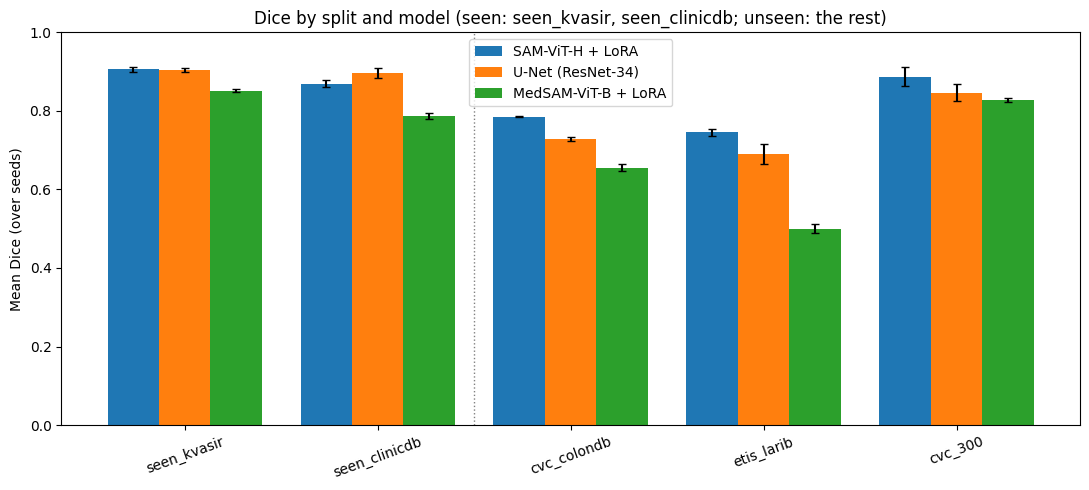

In [4]:
# Per-split breakdown: mean Dice per model per split, error bars = std over seeds.
# Prompt-free tier only (agg_prompt_free, defined in the cell above).
fig, ax = plt.subplots(figsize=(11, 5))
model_dirs_ordered = [e["model_dir"] for e in agg_prompt_free]
x = range(len(ALL_SPLITS))
width = 0.8 / len(model_dirs_ordered)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, model_dir in enumerate(model_dirs_ordered):
    e = agg_by_dir[model_dir]
    means = [e.get(f"{s}_mean") for s in ALL_SPLITS]
    stds = [e.get(f"{s}_std") for s in ALL_SPLITS]
    offsets = [xi + (i - (len(model_dirs_ordered) - 1) / 2) * width for xi in x]
    ax.bar(offsets, means, width=width, yerr=stds, capsize=3,
           label=MODEL_DISPLAY[model_dir], color=colors[i % len(colors)])

ax.set_xticks(list(x))
ax.set_xticklabels(ALL_SPLITS, rotation=20)
ax.set_ylabel("Mean Dice (over seeds)")
ax.set_title("Dice by split and model (seen: seen_kvasir, seen_clinicdb; unseen: the rest)")
ax.axvline(1.5, color="gray", linestyle=":", linewidth=1)
ax.set_ylim(0, 1.0)
ax.legend()
fig.tight_layout()
plt.show()


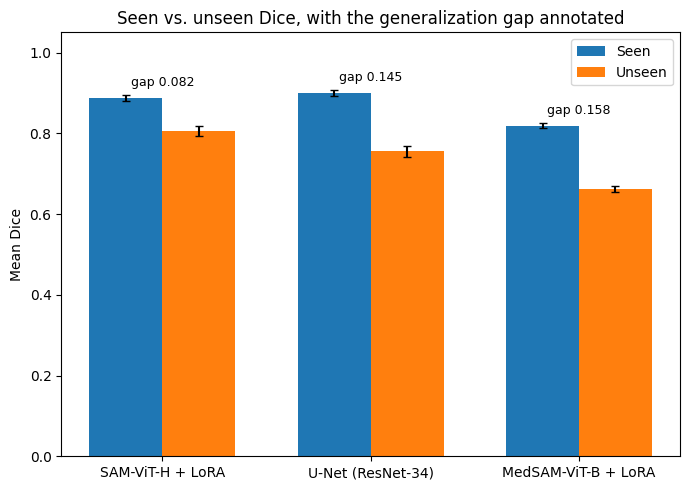

In [5]:
# Generalization gap: seen vs. unseen mean Dice per model, with the gap value annotated.
# Prompt-free tier only (agg_prompt_free).
fig, ax = plt.subplots(figsize=(7, 5))
labels = [MODEL_DISPLAY[e["model_dir"]] for e in agg_prompt_free]
seen_means = [e["mean_seen_dice_mean"] for e in agg_prompt_free]
seen_stds = [e["mean_seen_dice_std"] for e in agg_prompt_free]
unseen_means = [e["mean_unseen_dice_mean"] for e in agg_prompt_free]
unseen_stds = [e["mean_unseen_dice_std"] for e in agg_prompt_free]
gaps = [e["generalization_gap_dice_mean"] for e in agg_prompt_free]

x = range(len(labels))
w = 0.35
ax.bar([xi - w / 2 for xi in x], seen_means, width=w, yerr=seen_stds, capsize=3, label="Seen")
ax.bar([xi + w / 2 for xi in x], unseen_means, width=w, yerr=unseen_stds, capsize=3, label="Unseen")

for xi, seen_m, unseen_m, gap in zip(x, seen_means, unseen_means, gaps):
    top = max(seen_m, unseen_m) + 0.03
    ax.annotate(f"gap {gap:.3f}", xy=(xi, top), ha="center", fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel("Mean Dice")
ax.set_ylim(0, 1.05)
ax.set_title("Seen vs. unseen Dice, with the generalization gap annotated")
ax.legend()
fig.tight_layout()
plt.show()


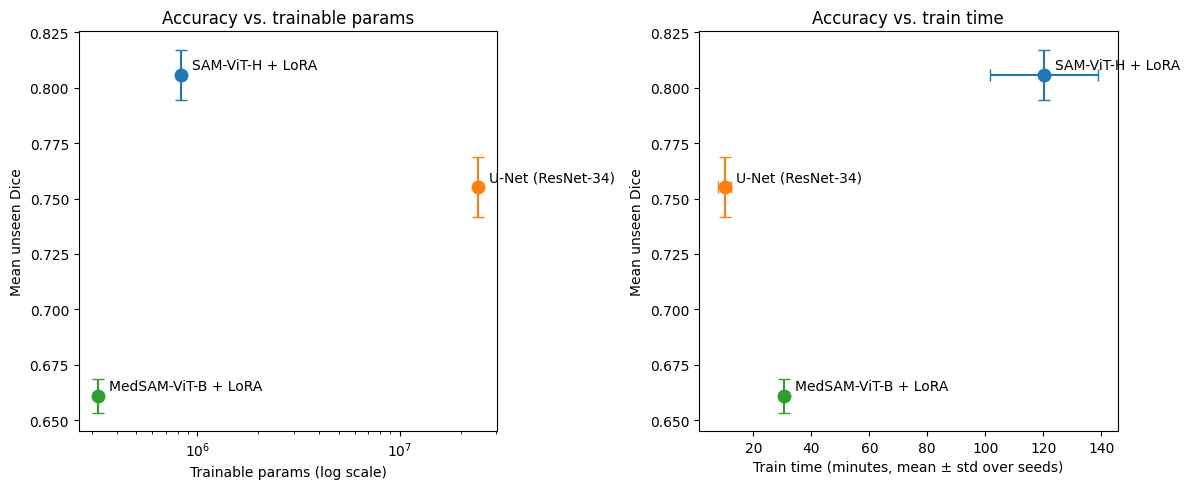

In [6]:
# Accuracy-per-cost: unseen Dice vs. trainable params (log x) and vs. train minutes.
# Prompt-free tier only (agg_prompt_free) — trainable params is 0 for every oracle row, which
# would collapse the log-x axis if it were included here.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for e in agg_prompt_free:
    label = MODEL_DISPLAY[e["model_dir"]]
    ax1.errorbar(e["trainable_params"], e["mean_unseen_dice_mean"],
                 yerr=e["mean_unseen_dice_std"], fmt="o", markersize=9, capsize=4)
    ax1.annotate(label, (e["trainable_params"], e["mean_unseen_dice_mean"]),
                 textcoords="offset points", xytext=(8, 4))
ax1.set_xscale("log")
ax1.set_xlabel("Trainable params (log scale)")
ax1.set_ylabel("Mean unseen Dice")
ax1.set_title("Accuracy vs. trainable params")

for e in agg_prompt_free:
    label = MODEL_DISPLAY[e["model_dir"]]
    ax2.errorbar(e["train_minutes_mean"], e["mean_unseen_dice_mean"],
                 xerr=e["train_minutes_std"], yerr=e["mean_unseen_dice_std"],
                 fmt="o", markersize=9, capsize=4)
    ax2.annotate(label, (e["train_minutes_mean"], e["mean_unseen_dice_mean"]),
                 textcoords="offset points", xytext=(8, 4))
ax2.set_xlabel("Train time (minutes, mean ± std over seeds)")
ax2.set_ylabel("Mean unseen Dice")
ax2.set_title("Accuracy vs. train time")

fig.tight_layout()
plt.show()


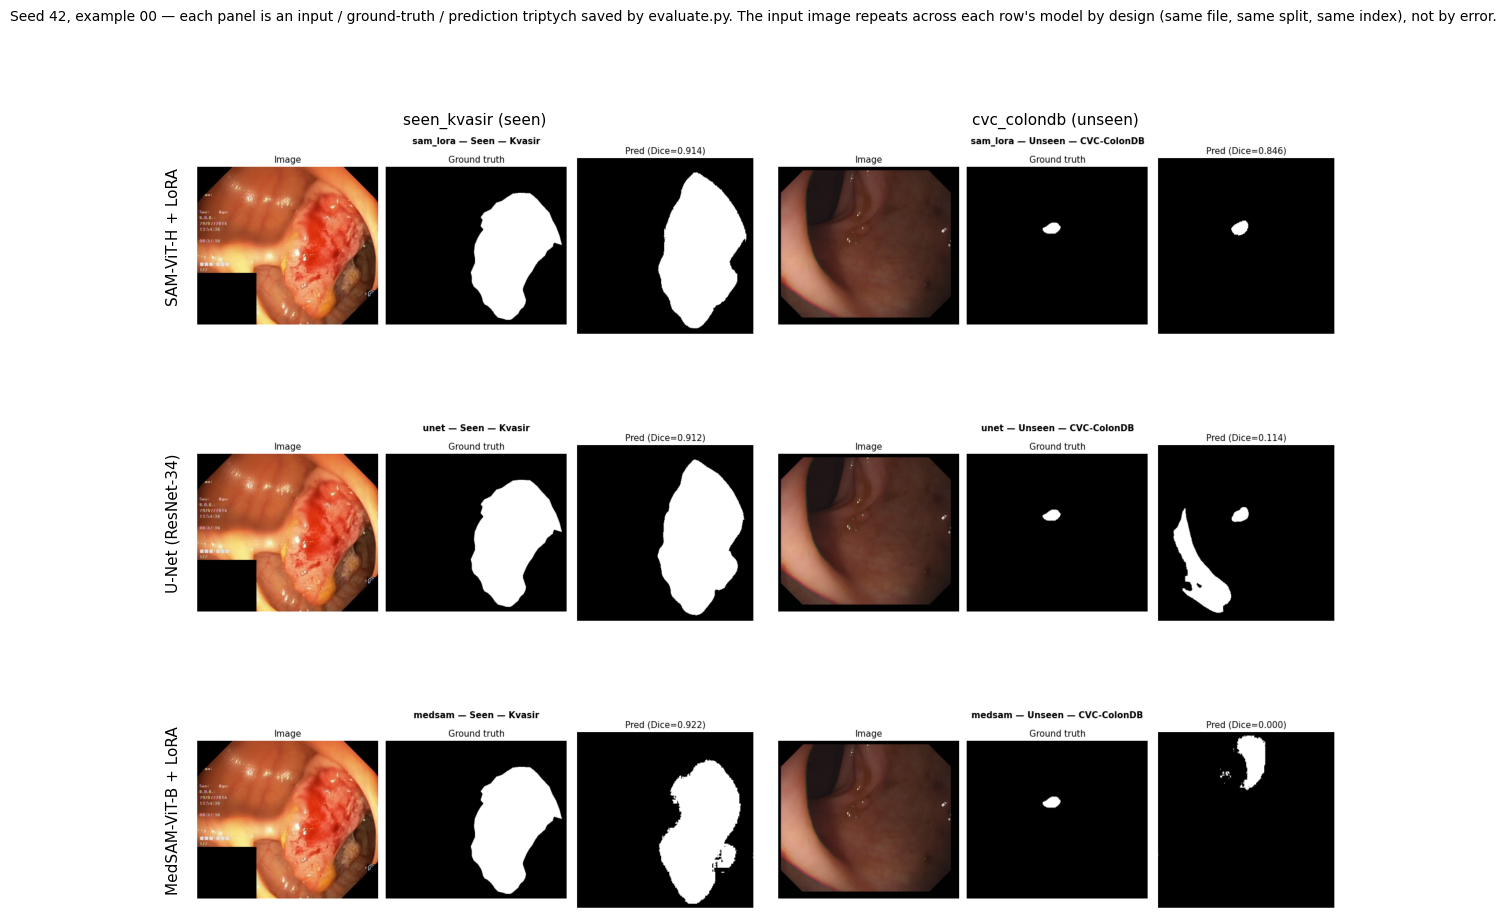

In [7]:
# Qualitative check: one seen (seen_kvasir) and one unseen (cvc_colondb) example per model, at
# seed 42 (the only seed with overlays saved for all three models). Fixed example index 00 is
# the SAME underlying image for every model — evaluate.py builds each split's DataLoader with
# shuffle=False over a sorted, fixed file listing (src/data/dataset.py), so index 00 always
# refers to the same file regardless of which model produced the prediction.
#
# Prompt-free tier only. The oracle baselines are seed0 with no overlay PNGs at all (they're
# never trained, so evaluate.py never runs on them) — including them here would look for
# nonexistent results/vanilla_sam/seed42/overlay_*.png and draw a phantom "overlay not found"
# row for a model that was never supposed to have one.
QUAL_SEED = 42
EXAMPLE_IDX = "00"
qual_splits = [("seen_kvasir", "seen"), ("cvc_colondb", "unseen")]
qual_model_dirs = [e["model_dir"] for e in agg
                    if e["model_dir"] in trained_model_dirs and tier_of(e["model_dir"]) == "prompt-free"]

fig, axes = plt.subplots(len(qual_model_dirs), len(qual_splits),
                          figsize=(6 * len(qual_splits), 3.2 * len(qual_model_dirs)))
if len(qual_model_dirs) == 1:
    axes = axes.reshape(1, -1)

missing_overlays = []
for i, model_dir in enumerate(qual_model_dirs):
    for j, (split, tag) in enumerate(qual_splits):
        ax = axes[i][j]
        png_path = RESULTS_DIR / model_dir / f"seed{QUAL_SEED}" / f"overlay_{split}_{EXAMPLE_IDX}.png"
        if png_path.is_file():
            ax.imshow(Image.open(png_path))
        else:
            ax.text(0.5, 0.5, "overlay not found", ha="center", va="center")
            missing_overlays.append(str(png_path))
        ax.axis("off")
        if i == 0:
            ax.set_title(f"{split} ({tag})", fontsize=11)
        if j == 0:
            ax.text(-0.02, 0.5, MODEL_DISPLAY[model_dir], transform=ax.transAxes,
                    ha="right", va="center", fontsize=11, rotation=90)

fig.suptitle(
    f"Seed {QUAL_SEED}, example {EXAMPLE_IDX} — each panel is an input / ground-truth / "
    f"prediction triptych saved by evaluate.py. The input image repeats across each row's "
    f"model by design (same file, same split, same index), not by error.",
    fontsize=10, y=1.02,
)
fig.tight_layout()
plt.show()

if missing_overlays:
    print(f"Missing overlay files: {missing_overlays}")


## Without fine-tuning — oracle-box baselines

Vanilla SAM-ViT-H and vanilla MedSAM-ViT-B, run with no LoRA and no training, prompted with a
box derived from the ground-truth mask. Zero trainable parameters; a prompt the trained models
above never get. This isolates fine-tuning itself, not backbone choice or generalization —
kept in its own table, never merged into the headline table above. A GT-derived box hands the
model the polyp's location, so a high score here is an upper bound on the task, not evidence of
better generalization; the tell is a negative seen-to-unseen gap, which the table below flags
directly.

Renders only when `results/vanilla_sam` and/or `results/vanilla_medsam` exist — written by
`05_benchmark.ipynb`'s zero-shot cell via `write_zeroshot_metrics`. Until that Colab run
happens, the cell below prints a one-line note and moves on.


In [8]:
# Oracle-box baselines: rendered from `agg`, filtered to the oracle tier — never the same
# table as the prompt-free headline above. Runtime-derived like not_yet_run_dirs: it renders
# only for whichever of vanilla_sam / vanilla_medsam actually has a metrics.json.
agg_oracle = [e for e in agg if tier_of(e["model_dir"]) == "oracle"]

if not agg_oracle:
    print("No oracle-box baselines under results/ yet. Run 05_benchmark.ipynb's zero-shot "
          "cell (writes results/vanilla_sam and results/vanilla_medsam), then re-run this "
          "notebook to populate this section.")
else:
    oracle_rows = []
    for e in agg_oracle:
        gap = e["generalization_gap_dice_mean"]
        oracle_rows.append({
            "Model": e["model"],
            "Seen mDice": _fmt_pm(e["mean_seen_dice_mean"], e["mean_seen_dice_std"]),
            "Unseen mDice": _fmt_pm(e["mean_unseen_dice_mean"], e["mean_unseen_dice_std"]),
            "Gap (seen−unseen)": f"{gap:+.4f}" if gap is not None else "—",
            "Trainable params": f"{e['trainable_params']:,}",
        })
    oracle_df = pd.DataFrame(oracle_rows)
    display(oracle_df)
    negative_gap = [e["model"] for e in agg_oracle
                    if (e["generalization_gap_dice_mean"] or 0) < 0]
    if negative_gap:
        print(f"Negative seen-to-unseen gap for: {', '.join(negative_gap)} — the oracle tell. "
              f"A GT box is equally informative on every split, so there is no seen-distribution "
              f"advantage for it to lose on unseen data the way a trained model has.")


No oracle-box baselines under results/ yet. Run 05_benchmark.ipynb's zero-shot cell (writes results/vanilla_sam and results/vanilla_medsam), then re-run this notebook to populate this section.


## Findings — the honest read

**SAM-ViT-H + LoRA generalizes best among the three trained models.** Unseen mean Dice is
0.806 ± 0.011 with the smallest seen-to-unseen gap, 0.082 ± 0.004, using only 0.83M trainable
parameters against a frozen 633M-parameter backbone. U-Net matches or edges out SAM-ViT-H on
the two seen splits (its native training distribution) but has the largest gap of the three
models, 0.145 ± 0.014 — it fits PraNet's own datasets closely and pays for that fit on unseen
ones. MedSAM + LoRA is weakest on every split, seen and unseen. Its backbone is ViT-B, smaller
than SAM-ViT-H's ViT-H, so this result mixes two variables — a different backbone size and a
different pretraining source — and cannot separate which one is responsible. That separation
needs SAM-ViT-B + LoRA (`sam_b`, same LoRA recipe and backbone size as MedSAM, SAM's
pretraining): once it is run, the SAM-ViT-H vs. SAM-ViT-B gap isolates backbone scale, and the
SAM-ViT-B vs. MedSAM gap isolates pretraining source.

**Limitations.** Everything above comes from one benchmark family, PraNet, evaluated on five
of its own splits — none of this speaks to performance on colonoscopy data collected under
different equipment or protocols. Each mean is over three seeds; the std columns above show
run-to-run spread is real but the sample is small. `sam_b` and the vanilla zero-shot baselines
are designed but not yet run (see the runtime-derived list in the models-compared table above)
— the backbone-confound question above is open until `sam_b` lands, and the fine-tuning-value
question (LoRA vs. none) is open until the zero-shot baselines run in `05_benchmark.ipynb` and
populate the "Without fine-tuning" section above. The qualitative panels above show one example
per split per model; they illustrate the mask quality the numbers describe, not a systematic
error analysis.
